### Задание

Создайте нейронную сеть, распознающую рукописные цифры. Используя подготовленную базу и шаблон ноутбука, нормируйте данные, создайте и обучите сверточную сеть.

**Параметры модели:** сеть должна содержать минимум 2 сверточных слоя; полносвязные слои; слои подвыборки, нормализации, регуляризации по 1 шт.

**Гиперпараметры обучения:** функция ошибки - категориальная кроссэнтропия, оптимизатор - Adam с шагом обучения одна тысячная, размер батча - 128, количество эпох 15, детали обучения - отображать.

**В конце** выведите график обучения: доли верных ответов на обучающей и проверочной выборках.


## 1. Загрузка датасета MNIST

In [12]:
import torch
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset_full = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

## 2. Импорт библиотек

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import random
from PIL import Image
from sklearn.model_selection import train_test_split

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

## 3. Визуализация примеров цифр

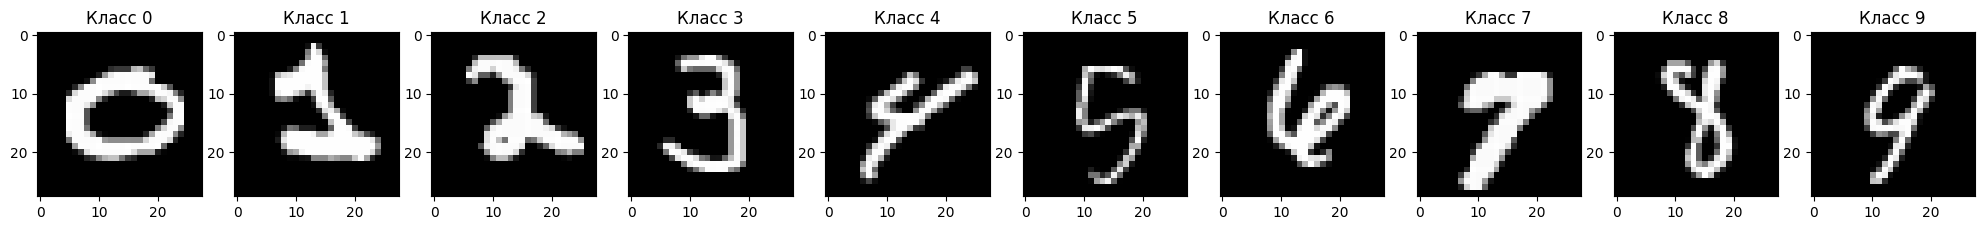

In [14]:
fig, axs = plt.subplots(1, 10, figsize=(25, 3))

for i in range(10):
    indices = [idx for idx, (_, label) in enumerate(train_dataset_full) if label == i]
    index = random.choice(indices)
    img, _ = train_dataset_full[index]
    img = img.squeeze().numpy()
    axs[i].imshow(img, cmap='gray')
    axs[i].set_title(f'Класс {i}')

plt.show()

## 4. Преобразование в numpy массивы

In [15]:
x_train_full = []
y_train_full = []

for img, label in train_dataset_full:
    x_train_full.append(img.numpy())
    y_train_full.append(label)

x_test = []
y_test = []

for img, label in test_dataset:
    x_test.append(img.numpy())
    y_test.append(label)

x_train_full = np.array(x_train_full)
y_train_full = np.array(y_train_full)
x_test = np.array(x_test)
y_test = np.array(y_test)

print(f"x_train_full: {x_train_full.shape}")
print(f"x_test: {x_test.shape}")
print(f"y_train_full: {y_train_full.shape}")
print(f"y_test: {y_test.shape}")

x_train_full: (60000, 1, 28, 28)
x_test: (10000, 1, 28, 28)
y_train_full: (60000,)
y_test: (10000,)


## 5. Нормализация и создание проверочной выборки

In [16]:
print(f"Диапазон значений: [{x_train_full.min()}, {x_train_full.max()}]")

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=10000,
    random_state=42,
    stratify=y_train_full
)

print(f"Обучающая: {x_train.shape}, Проверочная: {x_val.shape}, Тестовая: {x_test.shape}")

x_train_t = torch.tensor(x_train, dtype=torch.float32)
x_val_t = torch.tensor(x_val, dtype=torch.float32)
x_test_t = torch.tensor(x_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t = torch.tensor(y_val, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(x_train_t, y_train_t)
val_dataset = TensorDataset(x_val_t, y_val_t)
test_dataset = TensorDataset(x_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

Диапазон значений: [0.0, 1.0]
Обучающая: (50000, 1, 28, 28), Проверочная: (10000, 1, 28, 28), Тестовая: (10000, 1, 28, 28)


## 6. Создание модели

In [17]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bn = nn.BatchNorm2d(64)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 14 * 14, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = self.bn(x)
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNNModel().to(device)
print(f"Модель на устройстве: {device}")
print(model)

Модель на устройстве: cuda
CNNModel(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=12544, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


## 7. Компиляция модели

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 8. Обучение модели

In [19]:
epochs = 15
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):
    model.train()
    train_loss = 0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
    
    train_losses.append(train_loss / len(train_loader))
    train_accs.append(correct_train / total_train)
    
    model.eval()
    val_loss = 0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
    
    val_losses.append(val_loss / len(val_loader))
    val_accs.append(correct_val / total_val)
    
    print(f"Эпоха {epoch+1:2d}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accs[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.4f}")

Эпоха  1/15 | Train Loss: 0.1909 | Train Acc: 0.9430 | Val Loss: 0.0557 | Val Acc: 0.9826
Эпоха  2/15 | Train Loss: 0.0722 | Train Acc: 0.9778 | Val Loss: 0.0500 | Val Acc: 0.9860
Эпоха  3/15 | Train Loss: 0.0519 | Train Acc: 0.9836 | Val Loss: 0.0515 | Val Acc: 0.9859
Эпоха  4/15 | Train Loss: 0.0416 | Train Acc: 0.9864 | Val Loss: 0.0490 | Val Acc: 0.9876
Эпоха  5/15 | Train Loss: 0.0325 | Train Acc: 0.9898 | Val Loss: 0.0513 | Val Acc: 0.9876
Эпоха  6/15 | Train Loss: 0.0292 | Train Acc: 0.9905 | Val Loss: 0.0481 | Val Acc: 0.9893
Эпоха  7/15 | Train Loss: 0.0270 | Train Acc: 0.9911 | Val Loss: 0.0538 | Val Acc: 0.9874
Эпоха  8/15 | Train Loss: 0.0235 | Train Acc: 0.9922 | Val Loss: 0.0455 | Val Acc: 0.9895
Эпоха  9/15 | Train Loss: 0.0243 | Train Acc: 0.9924 | Val Loss: 0.0434 | Val Acc: 0.9900
Эпоха 10/15 | Train Loss: 0.0204 | Train Acc: 0.9931 | Val Loss: 0.0470 | Val Acc: 0.9897
Эпоха 11/15 | Train Loss: 0.0171 | Train Acc: 0.9944 | Val Loss: 0.0611 | Val Acc: 0.9873
Эпоха 12/1

## 9. График обучения

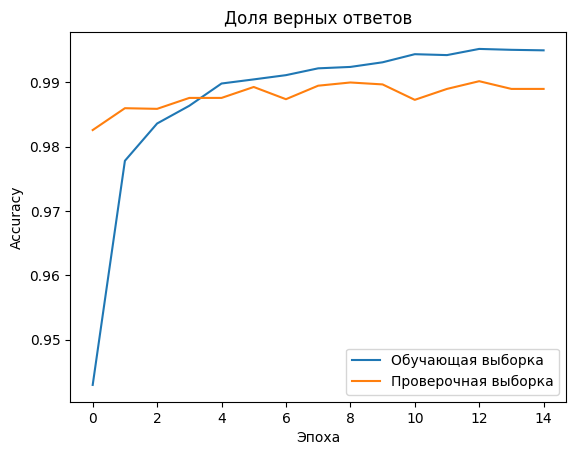

In [24]:
plt.plot(train_accs, label='Обучающая выборка')
plt.plot(val_accs, label='Проверочная выборка')

plt.title('Доля верных ответов')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

## 10. Оценка на тестовой выборке

In [21]:
model.eval()
correct_test = 0
total_test = 0
test_loss = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

test_acc = correct_test / total_test
print(f"Точность на тестовой выборке: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Ошибка на тестовой выборке: {test_loss / len(test_loader):.4f}")

Точность на тестовой выборке: 0.9906 (99.06%)
Ошибка на тестовой выборке: 0.0434


## 11. Сохранение модели

In [22]:
torch.save(model.state_dict(), "cnn_mnist_pytorch.pth")